In [84]:
% load_ext autoreload
% autoreload 2 

UsageError: Line magic function `%` not found.


In [1]:
import mod_loading as loader
from importlib import reload
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from tqdm import tqdm
import os
import ast

import gsw
import mod_argo
import matplotlib.pyplot as plt
import matplotlib.colors     as mpcolors
from cmocean import cm as cmo
import seaborn as sns
import mod_ocean as myocn
import mod_regression as mod_reg
import mod_preprocessing as mod_prep


# Import data

- Validation errors saved from 3.1_clustered_RFR


In [21]:
# ==== Choose which runs to retrieve
float_carbon_var= 'pHbias5_pK1'
pcm_params='pc8_gmm6'
n_gmm = int(pcm_params.split('_')[1][-1])

folder = '../working-vars/regression/storedRuns/' + pcm_params + '/'
# use_datetag = '20260126'  # gmm8
use_datetag = '20260122' # gmm6

In [22]:
# ====== Recover validation errors and store in dictionary, 
# Keys from run_tags (featurelist-trainingdata-targetvariable)
# Values from DF_err (validation errors collapsed over classes)

storedRuns_collapsed = {}
for filepath in sorted(os.listdir(folder)):
    # if filepath.endswith('.csv') & (filepath.startswith('model_acc' + use_datetag)):
    if filepath.endswith('.csv') & (filepath.startswith('model' + use_datetag)):
        runkey = filepath.split('_TAG_')[1].split('_PARAMS_')[0]
        # if 'excludeClass' in filepath:
        #     print('Importing model runs with excluded class: ' + runkey)
        storedRuns_collapsed[runkey] = pd.read_csv(folder + filepath, index_col=0)

if 'excludeClass' in filepath: # just use last path to see if classes were excluded
    print('Importing model runs with excluded class: ' + runkey)
print('Created new storedRuns_collapsed object with restored model errors for ' + use_datetag) 

# ===== Reconstruct ModelVersion object (see mod_regression) for each run 
storedRuns = {}
for run_tag, valErrors in storedRuns_collapsed.items():
    singleRun = mod_reg.ModelVersion(ind_list = valErrors.cluster.unique())
    singleRun.DF_err = {k:v for k, v in valErrors.groupby('cluster')}
    storedRuns[run_tag] = singleRun

Created new storedRuns_collapsed object with restored model errors for 20260122


In [23]:
storedRuns_collapsed

{'featA-combined-delta_pco2':              profid      wmoid      prof_datetag  cluster  \
 2673  5904678_id001  5904678.0  5904678_20160407        1   
 2674  5904678_id002  5904678.0  5904678_20160408        1   
 2675  5904678_id003  5904678.0  5904678_20160409        1   
 2676  5904678_id004  5904678.0  5904678_20160410        1   
 2677  5904678_id005  5904678.0  5904678_20160411        1   
 ...             ...        ...               ...      ...   
 6026            NaN        NaN               NaN        5   
 6037            NaN        NaN               NaN        5   
 6067            NaN        NaN               NaN        5   
 6068            NaN        NaN               NaN        5   
 6069            NaN        NaN               NaN        5   
 
                         datetime   latitude  longitude  linear_time     ydcos  \
 2673  2016-04-07 22:30:00.000000 -51.952000  148.66600   827.937500 -0.105170   
 2674  2016-04-08 22:52:00.000002 -51.991000  148.85400   828

In [24]:
# === Load feature lists used for each runkey
feat_options = {}
filename = ('storedRuns_featureLists_acc' + use_datetag + 
            '_PARAMS_floatparam_' + float_carbon_var + '_' + pcm_params + 
            '_excludeClass3.txt')
with open(folder + filename, 'r') as f:
    for line in f:
        tag, feats = line.strip().split('_',1)
        feat_options[tag] = ast.literal_eval(feats)
feat_options

FileNotFoundError: [Errno 2] No such file or directory: '../working-vars/regression/storedRuns/pc8_gmm6/storedRuns_featureLists_acc20260122_PARAMS_floatparam_pHbias5_pK1_pc8_gmm6_excludeClass3.txt'

# Error analyses and plots

In [6]:
# Store figure plotting functions in separate module
import figs_regression as figs_reg

<Axes: >

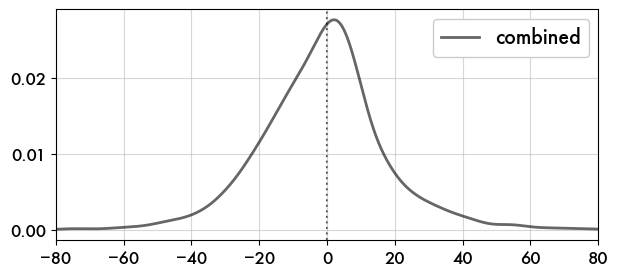

In [70]:
reload(figs_reg)
fig = plt.figure(figsize=(7,3))
ax = fig.gca()
figs_reg.singleRun_error_kde(storedRuns['featH-combined-delta_pco2'], ax=ax, xlim=80)

<Axes: >

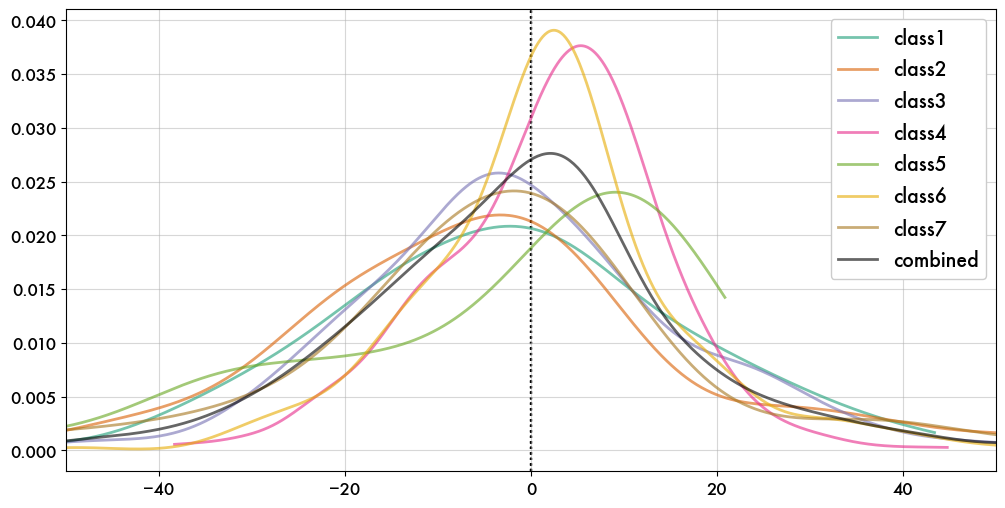

In [71]:
reload(figs_reg)
figs_reg.singleRun_error_kde(storedRuns['featH-combined-delta_pco2'], byClass = True)

<Axes: >

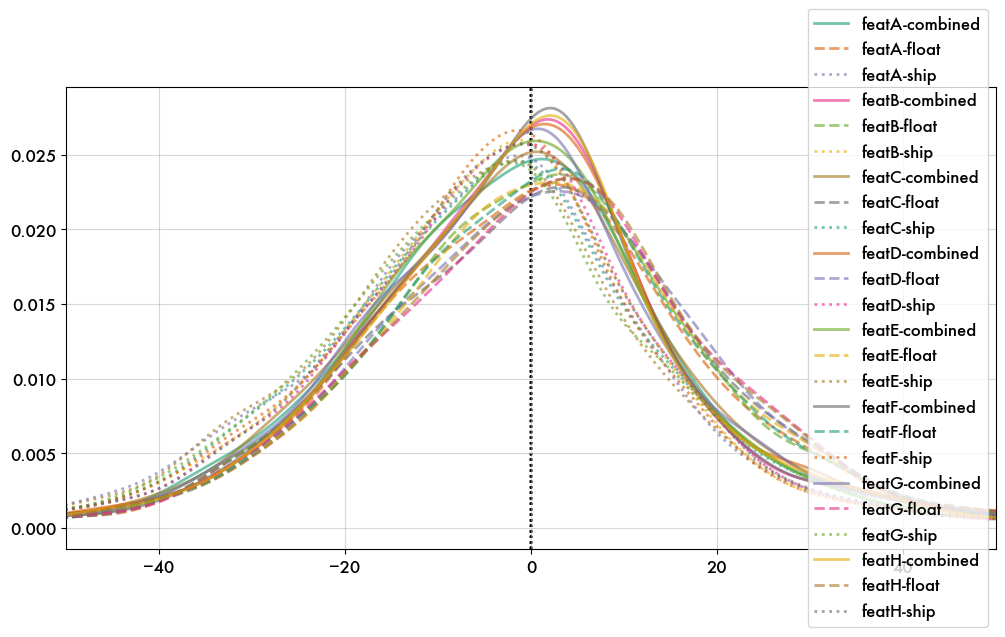

In [72]:
reload(figs_reg)
figs_reg.storedRuns_error_kde(storedRuns, xlim=50)
# figs_reg.storedRuns_error_kde(storedRuns_gmm8_ex3, xlim=100, show_legend=False)

In [73]:
reload(mod_reg)
mod_reg.singleRun_platform_summary(singleRun)

,median_AE,mean_AE,bias,rmse
overall,9.869846,13.618939,-1.297678,18.673313
float_component,12.000766,15.451124,-3.020562,20.503912
ship_component,7.349044,10.133987,1.979375,14.569836


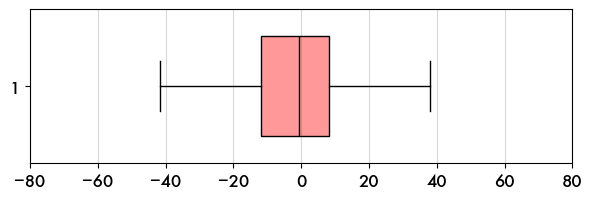

In [74]:
reload(figs_reg)
ax = figs_reg.singleRun_error_boxplot(storedRuns['featH-combined-delta_pco2'], byClass = False, xlims=[-80,80], boxcolor='red')
# figs_reg.singleRun_error_boxplot(storedRuns['featA-combined-delta_pco2'], ax=ax, byClass = False, xlims=[-80,80], boxcolor='green')

(0.2, 7.8)

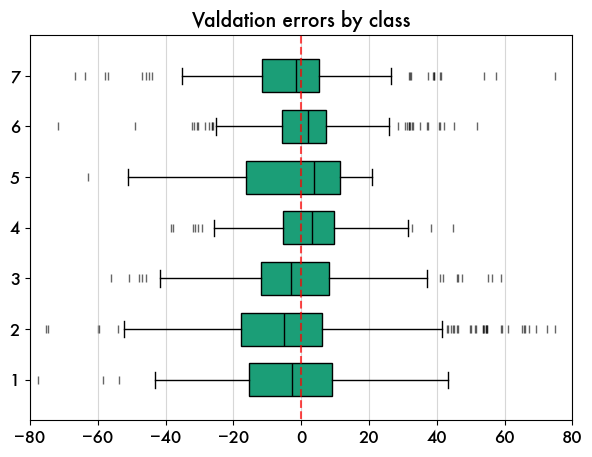

In [75]:
reload(figs_reg)

ax = figs_reg.singleRun_error_boxplot(storedRuns['featH-combined-delta_pco2'], byClass = True, xlims=[-80,80])
ax.set_title('Valdation errors by class')
ax.vlines(0, ymin=0, ymax=8, color='r', linestyles='dashed', alpha=0.7, zorder=3)
ax.set_ylim([0.2,7.8])


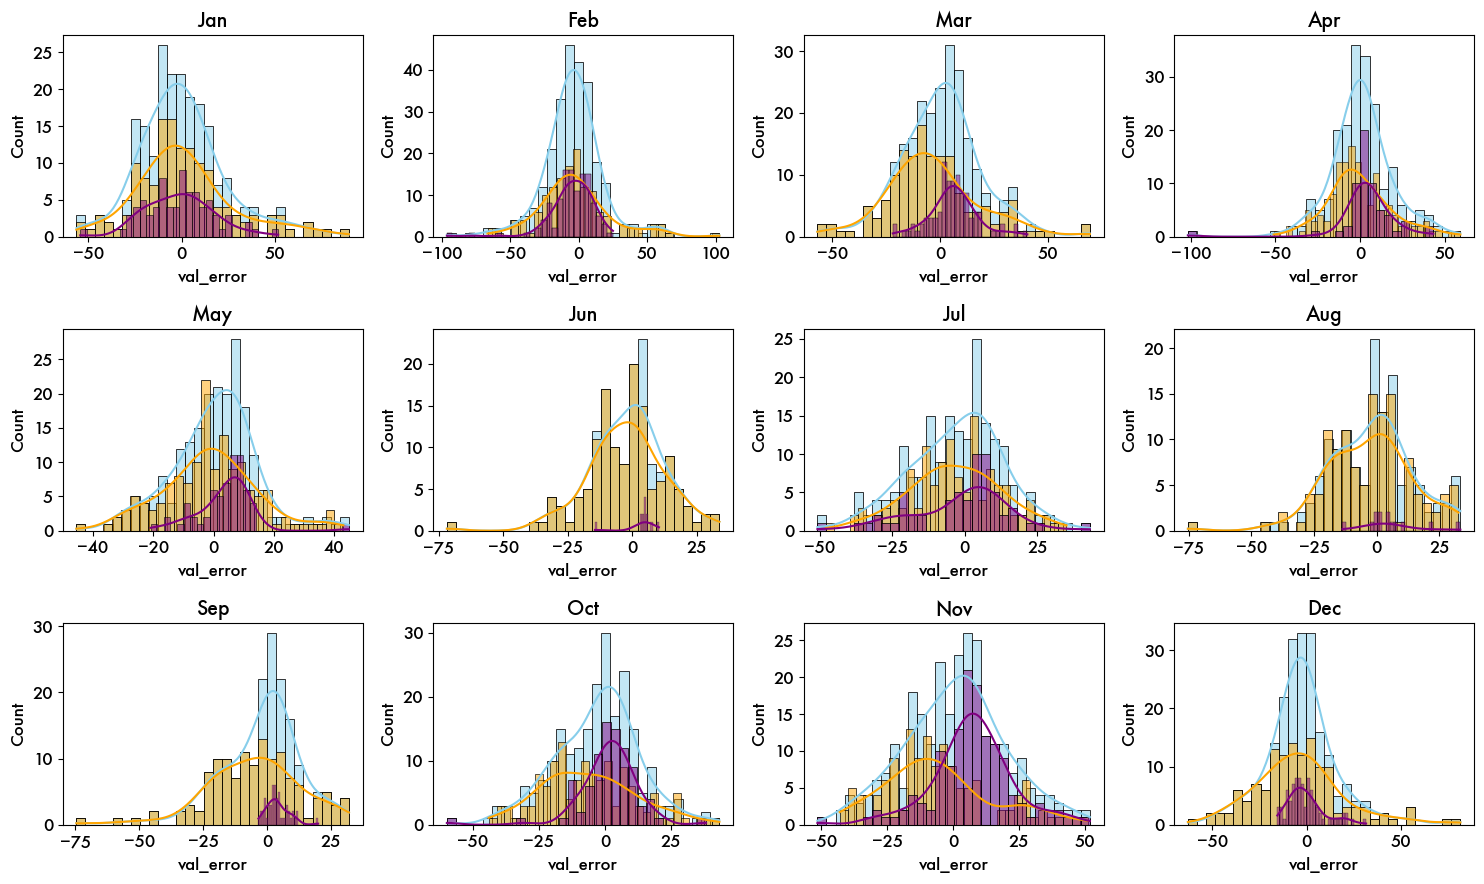

In [ ]:
# Distributions by month
singleRun = storedRuns['featH-combined-delta_pco2']
valDF_combined = myocn.expand_datetime(mod_reg.singleRun_collapse_errors(singleRun), type='dataframe')
[valDF_float, valDF_ship] = mod_reg.separate_platforms(valDF_combined)

# == plot
fig, axs = plt.subplots(3,4, figsize=(15,9), layout='tight')
axs = axs.flatten()

monthlist = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for monthnum in range(1,13):
    ax = axs[monthnum-1]

    plot_data = valDF_combined[valDF_combined.month == monthnum]
    sns.histplot(plot_data['val_error'], bins=30, kde=True, ax=ax, color='skyblue')

    plot_data = valDF_float[valDF_float.month == monthnum]
    sns.histplot(plot_data['val_error'], bins=30, kde=True, ax=ax, color='orange')

    plot_data = valDF_ship[valDF_ship.month == monthnum]
    sns.histplot(plot_data['val_error'], bins=30, kde=True, ax=ax, color='purple')


    ax.set_title(monthlist[monthnum-1], fontsize=14)


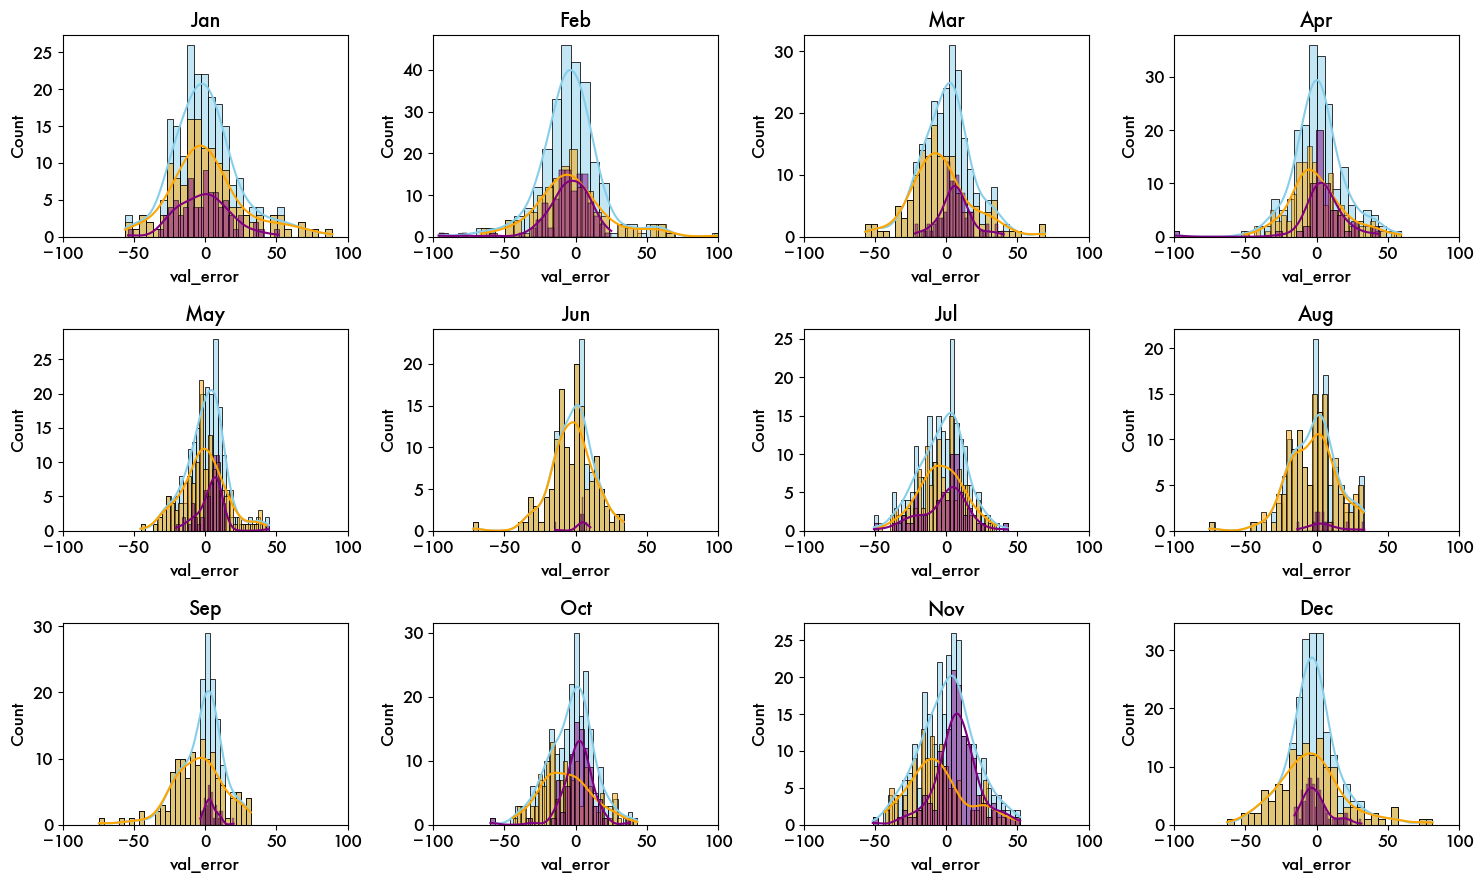

In [83]:
reload(figs_reg)
fig, axs = figs_reg.error_histplot_paneled_monthly(error_sets=[valDF_combined, valDF_float, valDF_ship]);
for ax in axs:
    ax.set_xlim([-100,100])

In [ ]:
reload(figs_reg)
# from figs_datadistributions import datatype_colors
singleRun = storedRuns_weighted_gmm6['featD-combined-delta_pco2']
valDF_combined = myocn.expand_datetime(singleRun.weighted_validation, type='dataframe')
[valDF_float, valDF_ship] = mod_reg.separate_platforms(valDF_combined)

# === OPTION 
# fig, axs = figs_reg.error_histplot_paneled_monthly(error_sets=[valDF_combined, valDF_float, valDF_ship],
#                                                    nbins=20,
#                                                 colors = ['skyblue', 'orange', 'blue'],
#                                                 stat_type='percent',
#                                                 zero_line = True, error_lim=100, alphas=[0.8, 0.8, 0.6]);
# axs[-1].legend(['combined', 'float', 'ship'])

# === OPTION 
fig, axs = figs_reg.error_histplot_paneled_monthly(error_sets=[valDF_float, valDF_ship],
                                                   nbins=15,
                                                colors = ['orange', 'blue'],
                                                stat_type='percent',
                                                zero_line = True, error_lim=100, alphas=[0.8, 0.6]);
axs[-1].legend(['float', 'ship'])

# === OPTION 
# fig, axs = figs_reg.error_histplot_paneled_monthly(error_sets=[valDF_combined],
#                                                    nbins=20,
#                                                 colors = ['teal'],
#                                                 stat_type='percent',
#                                                 zero_line = True, error_lim=100, alphas=[0.8, 0.8, 0.6]);
# axs[-1].legend(['combined'])
# for ax in axs: 
#     ax.vlines(0, ymin=0, ymax=28, colors='r', linewidth=2, linestyles='dashed', alpha=0.6)
#     ax.set_ylim([0,25])

